In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.features import get_wt_seq


X_df = pd.read_pickle('../data/processed/X_df.pkl')
X_df = get_wt_seq(X_df)
y_df = pd.read_pickle('../data/processed/y_df.pkl')

## Create new dataset
finetune_df = X_df[['WT_name', 'wt_aa_seq', 'aa_seq', 'position']].copy()
finetune_df["ddG"] = y_df.to_numpy()
finetune_df.head()

We now split up the data into train, validate, and test set, while grouping by "WT_name" to prevent data leakage and that the model is evaluated on proteins it has never seen before.

In [2]:

from sklearn.model_selection import GroupShuffleSplit

groups = finetune_df["WT_name"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

## Get the trainval and test dataset
trainval_idx, test_idx = next(splitter.split(finetune_df, groups=groups))

trainval_df = finetune_df.iloc[trainval_idx].copy()
test_df = finetune_df.iloc[test_idx].copy()


## Split the trainval dataset into train and valdiate
groups = trainval_df["WT_name"]
train_idx, val_idx = next(splitter.split(trainval_df, groups=groups))

train_df = trainval_df.iloc[train_idx].copy()
val_df = trainval_df.iloc[val_idx].copy()


Check and ensure no data leakage.

In [18]:
train_wt = set(train_df["WT_name"])
val_wt = set(val_df["WT_name"])
test_wt = set(test_df["WT_name"])

print("Train/val overlap:", len(train_wt & val_wt))
print("Train/test overlap:", len(train_wt & test_wt))
print("Val/test overlap:", len(val_wt & test_wt))

Train/val overlap: 0
Train/test overlap: 0
Val/test overlap: 0


I defined a dataset class (StabilityDataset) that returns a dictionary containing the wt_seq, mut_seq, mutation position, and the experimentally obtained ddG score. 

In [4]:
from src.data import StabilityDataset
train_dataset = StabilityDataset(train_df)
val_dataset = StabilityDataset(val_df)
test_dataset = StabilityDataset(test_df)

The next step is to pass out dataset into a dataloader. However, dataloader expects tensors and out dataset contains strings and integers. We therefore need to write a collate function that tells the dataloader how to handle the dataset. The collate function will turn the non tensor datasets into tensor datasets using the ESM-2 tokenizer. The dataloader can pass on the tokenized tensor data in batches.

In [ ]:
from src.embeddings import make_collate_fn
from transformers import AutoTokenizer, AutoModel

## Download the ESM-2 model and tokenizer
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = AutoModel.from_pretrained(model_name)

## Initiate the collate function with the ESM-2 tokenizer that will be passed to the dataloader
collate_fn = make_collate_fn(tokenizer)

Now we pass the datasets for the train, validate, test splits to the dataloaders along with our defined collate function. 

In [10]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    StabilityDataset(train_df),
    batch_size=128,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    StabilityDataset(val_df),
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    StabilityDataset(test_df),
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn
)

Wrote a model called ESMDeltaGRegressor that creates a ddG prediction. It does the following.

1. Takes wt_seq/mut_seq/positions from the Dataloader
2. Passes the tokenized wt_seq/mut_seq to esm-2 model to get embeddings
3. Extracts the 320 length embeddings coresponding to the specific mut/wt residue encoded by position
4. Calculates delta_embedding: mut_embedding - wt_embeddings
5. Feeds the delta_embedding through single hidden state linear layer to get ddG prediction

The original ESM_model has 6 layers. I will freeze all but the last layer and atempt to train my ddG predictive model on this. 
I wrote a function freeze_esm_except_last_n which does just this.

In [ ]:
from src.models import ESMDeltaGRegressor
from src.models import freeze_esm_except_last_n
import torch
from transformers import AutoTokenizer, AutoModel

## Use my computer's GPU over CPU for effiency
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

## Load ESM2 and define model and tokenizer
model_name = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = AutoModel.from_pretrained(model_name)

model = ESMDeltaGRegressor(
    esm_model=esm_model,
    embedding_dim=320,
    hidden_dim=128,
    dropout=0.2
)
           
## Freeze all but last layer of ESM2
freeze_esm_except_last_n(model, n_layers=1)

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

I have written a training function that incorporates early stopping and differential optimizer learning rates for the unfrozen ESM-2 layer and the regression head. I will run through the model using lower values than normal like patienc = 4 and num_epochs = 15, due to the very long run time. 

In [ ]:
from src.train import train_finetune


tuned_model, history = train_finetune(train_loader, model, device, num_epochs=15, lr_esm = 1e-4, lr_reghead = 1e-4, weight_decay = 1e-4, validation_dataloader = val_loader, 
patience = 4, min_delta = 0.001)

Ok, I was a bit light handed here with the training due to compute constraint. However we do see overfitting of the training data but very limited if at all improvement of the valuation data. Lets create the plot and then evaluate it on the test data. 

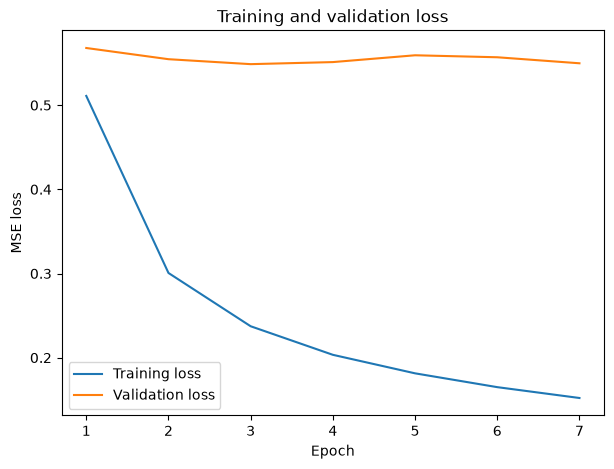

In [32]:
epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], label="Training loss")
plt.plot(epochs, history["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.legend()
plt.savefig(
    "../figures/esm_finetuning_training.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
## Evaluate the model on the test set
from src.evaluate import evaluate_finetune
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
## The outputed model should be the best version

average_loss, all_predictions, all_targets = evaluate_finetune(test_loader, tuned_model, device)

y_pred = all_predictions.numpy()
y_true = all_targets.numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)
rho, p_value = spearmanr(y_true, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Spearman rho:", rho)
print("p-value:", p_value)

#MAE: 0.49949949979782104
#RMSE: 0.684414115206003
#R²: 0.5312910079956055
#Spearman rho: 0.7049943097941195
#p-value: 0.0

MAE: 0.49949949979782104
RMSE: 0.684414115206003
R²: 0.5312910079956055
Spearman rho: 0.7049943097941195
p-value: 0.0


Partial fine-tuning improved held-out protein generalization, but the widening train–validation gap indicates substantial overfitting after the first few epochs.

However, this model still performs by far the best out of the previous methods I tried. 
- Biochemical Ridge             R² ~0.13
- Biochemical Random Forest     R² ~0.38
- Frozen ESM + Ridge            R² ~0.28
- Frozen ESM + MLP              R² ~0.45
- Partial ESM fine-tuning       R² ~0.53

This demonstrates that even the most basic transfer learning applied on the ESM-2 model yields by far the best performance.

I want to try and improve the current performance a bit more keeping in mind the ~10 hour training/validation time. 

First, I will reduce the regression head from 128 to 64. Although this reduces the capacity of the model to learn the overall data, it is clearly learning training specific patterns and this overfitting. By reducing head to 64 this should hopefully curtail that behavior. 

Additionally I incorporated the option of using a differential optimizer learning rates for the unfrozen ESM-2 layer and the regression head. I will use a lower learning rate for the already trained ESM-2 unfrozen layer, and a faster training rate for the regression head. Hopefully this will preven catastrophic forgetting. Great term.

In [ ]:
from src.train import train_finetune
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)
model_name = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = AutoModel.from_pretrained(model_name)

model = ESMDeltaGRegressor(
    esm_model=esm_model,
    embedding_dim=320,
    hidden_dim=64,    ## Here I reduce the head
    dropout=0.2
)
           
freeze_esm_except_last_n(model, n_layers=1)

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)


## I also halved the learning rate
tuned2_model, history2 = train_finetune(train_loader, model, device, num_epochs=15, lr_esm = 5e-5, lr_reghead = 1e-3, weight_decay = 1e-4, validation_dataloader = val_loader, 
patience = 4, min_delta = 0.001)

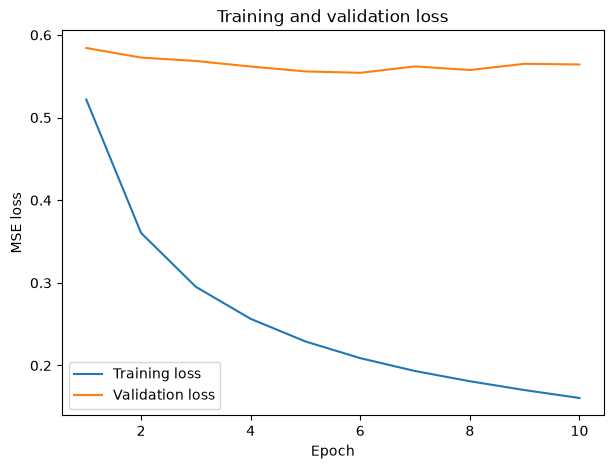

In [ ]:
epochs = range(1, len(history2["train_loss"]) + 1)
plt.figure(figsize=(7, 5))
plt.plot(epochs, history2["train_loss"], label="Training loss")
plt.plot(epochs, history2["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Get evaluation data for this tuned model.

In [ ]:
## Evaluate the model on the test set
from src.evaluate import evaluate_finetune
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
## The outputed model should be the best version

average_loss, all_predictions, all_targets = evaluate_finetune(test_loader, tuned2_model, device)

y_pred = all_predictions.numpy()
y_true = all_targets.numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)
rho, p_value = spearmanr(y_true, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Spearman rho:", rho)
print("p-value:", p_value)
#MAE: 0.5019763112068176
#RMSE: 0.6872984200506479
#R²: 0.5273321866989136
#Spearman rho: 0.7041566289445584
#p-value: 0.0

MAE: 0.5019763112068176
RMSE: 0.6872984200506479
R²: 0.5273321866989136
Spearman rho: 0.7041566289445584
p-value: 0.0


So after reducing regression head and applying differential learning rates the performance dropped very slightly: R² 0.531 to 0.527. Looks like the overfitting on the training data is comming from the ESM-2 model itself not from the regression head. It will take quite a but of compute to try and improve further. Fine-tuning hyperparameters and unfreezing more layers will likely result in improvements however if each run is around ~10 hours then this could take quite some time. I think I will call it here, save the best model below, and move onto predicting protein stability. 

In [30]:
import torch

checkpoint = {
    "model_state_dict": tuned_model.state_dict(),
    "history": history,
    "embedding_dim": 320,
    "hidden_dim": 128,
    "dropout": 0.2,
    "n_unfrozen_layers": 1,
    "lr": 1e-4,
    "weight_decay": 1e-4,
}

torch.save(
    checkpoint,
    "../data/processed/esm_finetuned_checkpoint.pt"
)

import pickle

with open("../data/processed/finetune_history.pkl", "wb") as f:
    pickle.dump(history, f)

In [29]:
checkpoint_test = torch.load(
    "../data/processed/esm_finetuned_checkpoint.pt",
    map_location="cpu"
)

print(checkpoint_test.keys())

dict_keys(['model_state_dict', 'history', 'embedding_dim', 'hidden_dim', 'dropout', 'n_unfrozen_layers', 'lr', 'weight_decay'])
